In [4]:
import pandas as pd
import numpy as np

In [5]:
# preprocessing tools
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score


from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

import matplotlib.pyplot as plt
import seaborn as sns

# New imports for detailed metrics
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

In [6]:
pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


# Load Dataset

In [7]:
data = pd.read_csv("credit_risk.csv")
data.head()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


# Feature Description

* SeriousDlqin2yrs:  Target variable – 1 if person defaulted in 2 years
* RevolvingUtilizationOfUnsecuredLines:	 % of credit limit used (credit cards, personal loans)
* *age:  Age of the person
* NumberOfTime30-59DaysPastDueNotWorse:  Times payment was 30–59 days late
* DebtRatio:  Monthly debt / monthly income
* MonthlyIncome:  Monthly income
* NumberOfOpenCreditLinesAndLoans:	Active loans + credit cards
* NumberOfTimes90DaysLate:	Times payment was 90+ days late
* NumberRealEstateLoansOrLines:	 Home/property loans
* NumberOfTime60-89DaysPastDueNotWorse:	 Times payment was 60–89 days late
* NumberOfDependents:  Family members dependent on income

In [10]:
data.shape

(150000, 12)

In [19]:
data.head()


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [8]:
data = data.drop(columns=['Unnamed: 0'], errors='ignore')

In [9]:
data.shape

(150000, 11)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      150000 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 2   age                                   150000 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 4   DebtRatio                             150000 non-null  float64
 5   MonthlyIncome                         120269 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 7   NumberOfTimes90DaysLate               150000 non-null  int64  
 8   NumberRealEstateLoansOrLines          150000 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 10  NumberOfDependents                    146076 non-null  float64
dtype

In [12]:
data["DebtRatio"]

0            0.802982
1            0.121876
2            0.085113
3            0.036050
4            0.024926
             ...     
149995       0.225131
149996       0.716562
149997    3870.000000
149998       0.000000
149999       0.249908
Name: DebtRatio, Length: 150000, dtype: float64

In [16]:
data.describe() 

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.202690e+05,150000.000000,150000.000000,150000.000000,150000.000000,146076.000000
mean,0.066840,6.048438,52.295207,0.421033,353.005076,6.670221e+03,8.452760,0.265973,1.018240,0.240387,0.757222
std,0.249746,249.755371,14.771866,4.192781,2037.818523,1.438467e+04,5.145951,4.169304,1.129771,4.155179,1.115086
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.029867,41.000000,0.000000,0.175074,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,0.000000,0.559046,63.000000,0.000000,0.868254,8.249000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


# Outlier Detection

In [24]:
excluded = ['SeriousDlqin2yrs']
cols = [col for col in data.columns if col not in excluded]
cols

['RevolvingUtilizationOfUnsecuredLines',
 'age',
 'NumberOfTime30-59DaysPastDueNotWorse',
 'DebtRatio',
 'MonthlyIncome',
 'NumberOfOpenCreditLinesAndLoans',
 'NumberOfTimes90DaysLate',
 'NumberRealEstateLoansOrLines',
 'NumberOfTime60-89DaysPastDueNotWorse',
 'NumberOfDependents']

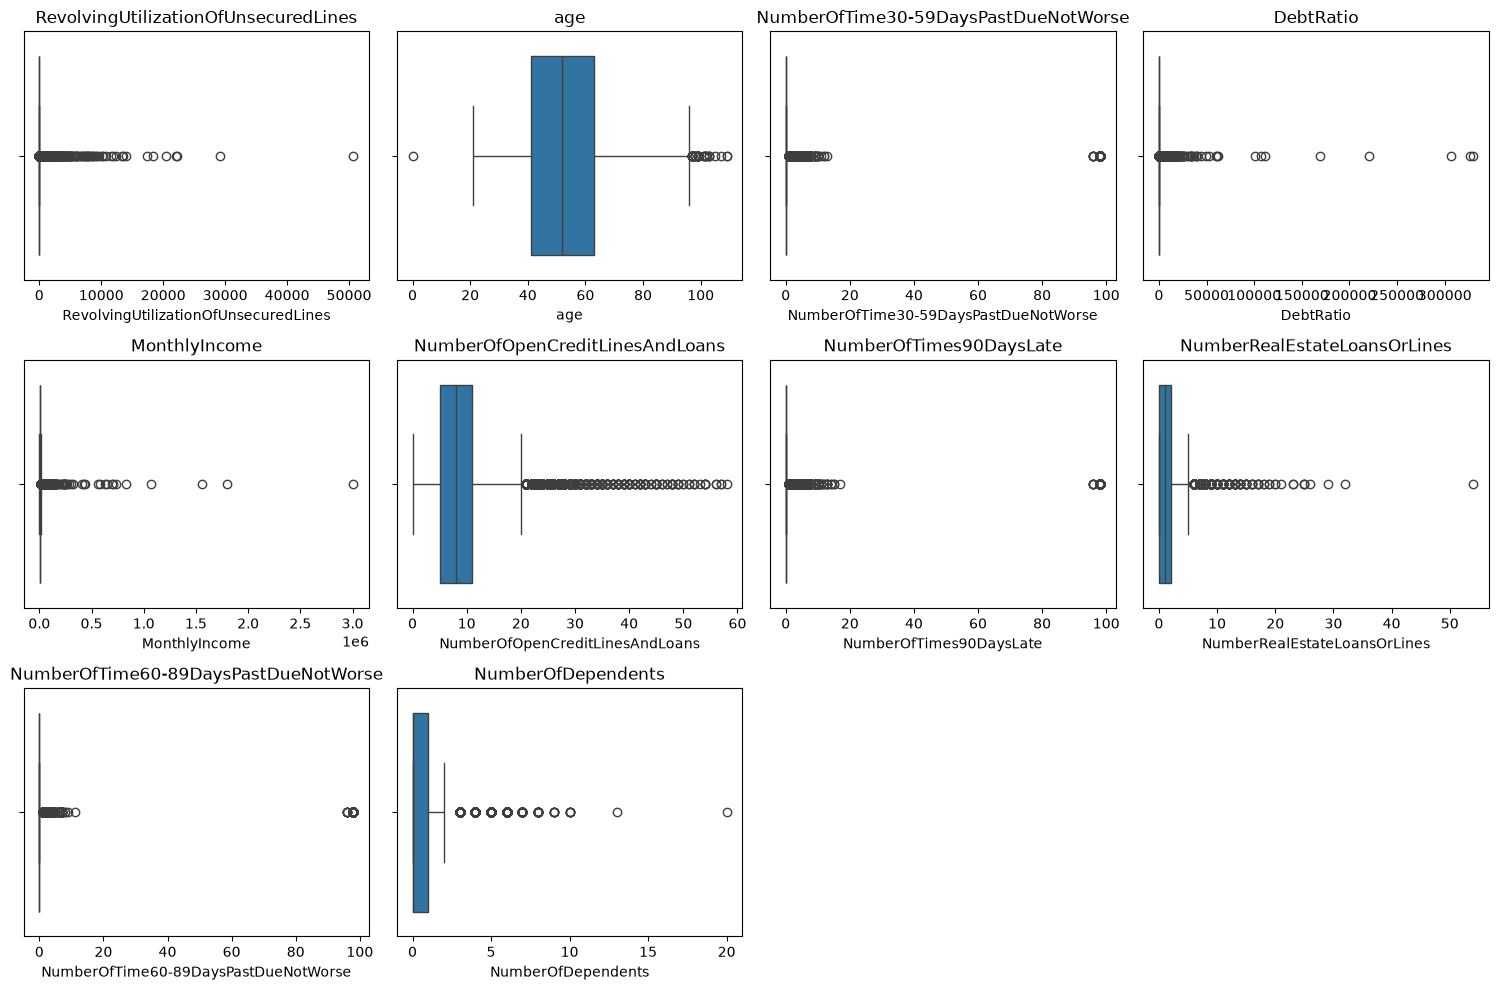

In [25]:
plt.figure(figsize=(15,10))

for i, col in enumerate(cols):
    plt.subplot(3,4,i+1)
    sns.boxplot(x=data[col])
    plt.title(col)

plt.tight_layout()
plt.show()

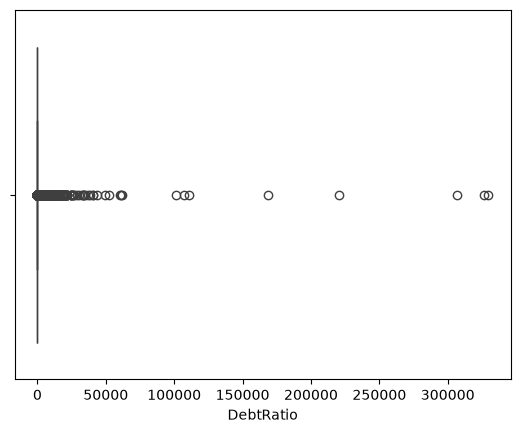

In [28]:
sns.boxplot(x=data["DebtRatio"])
plt.show()


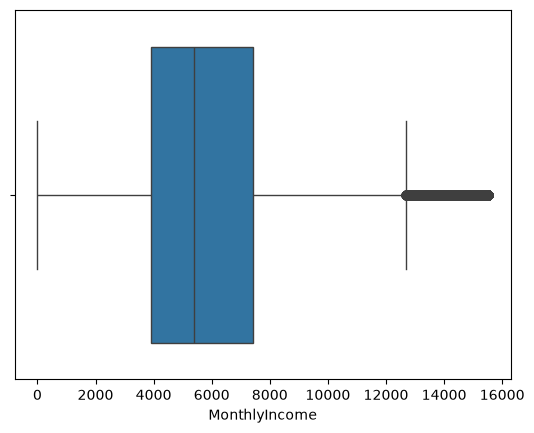

In [69]:
sns.boxplot(x=data["MonthlyIncome"])
plt.show()

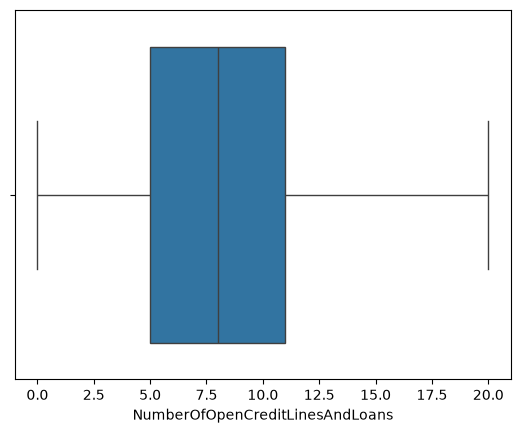

In [71]:
sns.boxplot(x=data["NumberOfOpenCreditLinesAndLoans"])
plt.show()

# Cap is set to 10 because value >10 don't add meaningful new risk info un delinquency counts

In [72]:
delinq_cols = [
    'NumberOfTime30-59DaysPastDueNotWorse',
    'NumberOfTime60-89DaysPastDueNotWorse',
    'NumberOfTimes90DaysLate'
]
for col in delinq_cols:
    data[col] = data[col].clip(upper=10) 

In [114]:
df=data['RevolvingUtilizationOfUnsecuredLines'].unique()
df.shape

(121889,)

In [113]:
data[(data['RevolvingUtilizationOfUnsecuredLines'] > 1) & (data['SeriousDlqin2yrs'] == 1)].count()

SeriousDlqin2yrs                        0
RevolvingUtilizationOfUnsecuredLines    0
age                                     0
NumberOfTime30-59DaysPastDueNotWorse    0
DebtRatio                               0
MonthlyIncome                           0
NumberOfOpenCreditLinesAndLoans         0
NumberOfTimes90DaysLate                 0
NumberRealEstateLoansOrLines            0
NumberOfTime60-89DaysPastDueNotWorse    0
NumberOfDependents                      0
DebtRatio_log                           0
dtype: int64

In [75]:
data[data['RevolvingUtilizationOfUnsecuredLines'] < 1].count()

SeriousDlqin2yrs                        145848
RevolvingUtilizationOfUnsecuredLines    145848
age                                     145848
NumberOfTime30-59DaysPastDueNotWorse    145848
DebtRatio                               145848
MonthlyIncome                           145848
NumberOfOpenCreditLinesAndLoans         145848
NumberOfTimes90DaysLate                 145848
NumberRealEstateLoansOrLines            145848
NumberOfTime60-89DaysPastDueNotWorse    145848
NumberOfDependents                      145848
DebtRatio_log                           145848
dtype: int64

# Once utilization crosses 100%, risk is already maximized

In [76]:
data['RevolvingUtilizationOfUnsecuredLines'] = (
    data['RevolvingUtilizationOfUnsecuredLines'].clip(upper=1))

C:\Users\PRAKASH KANAUJIYA\AppData\Local\Temp\ipykernel_18092\3318882915.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data['age'])
C:\Users\PRAKASH KANAUJIYA\AppData\Local\Temp\ipykernel_18092\3318882915.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data['NumberOfOpenCreditLinesAndL

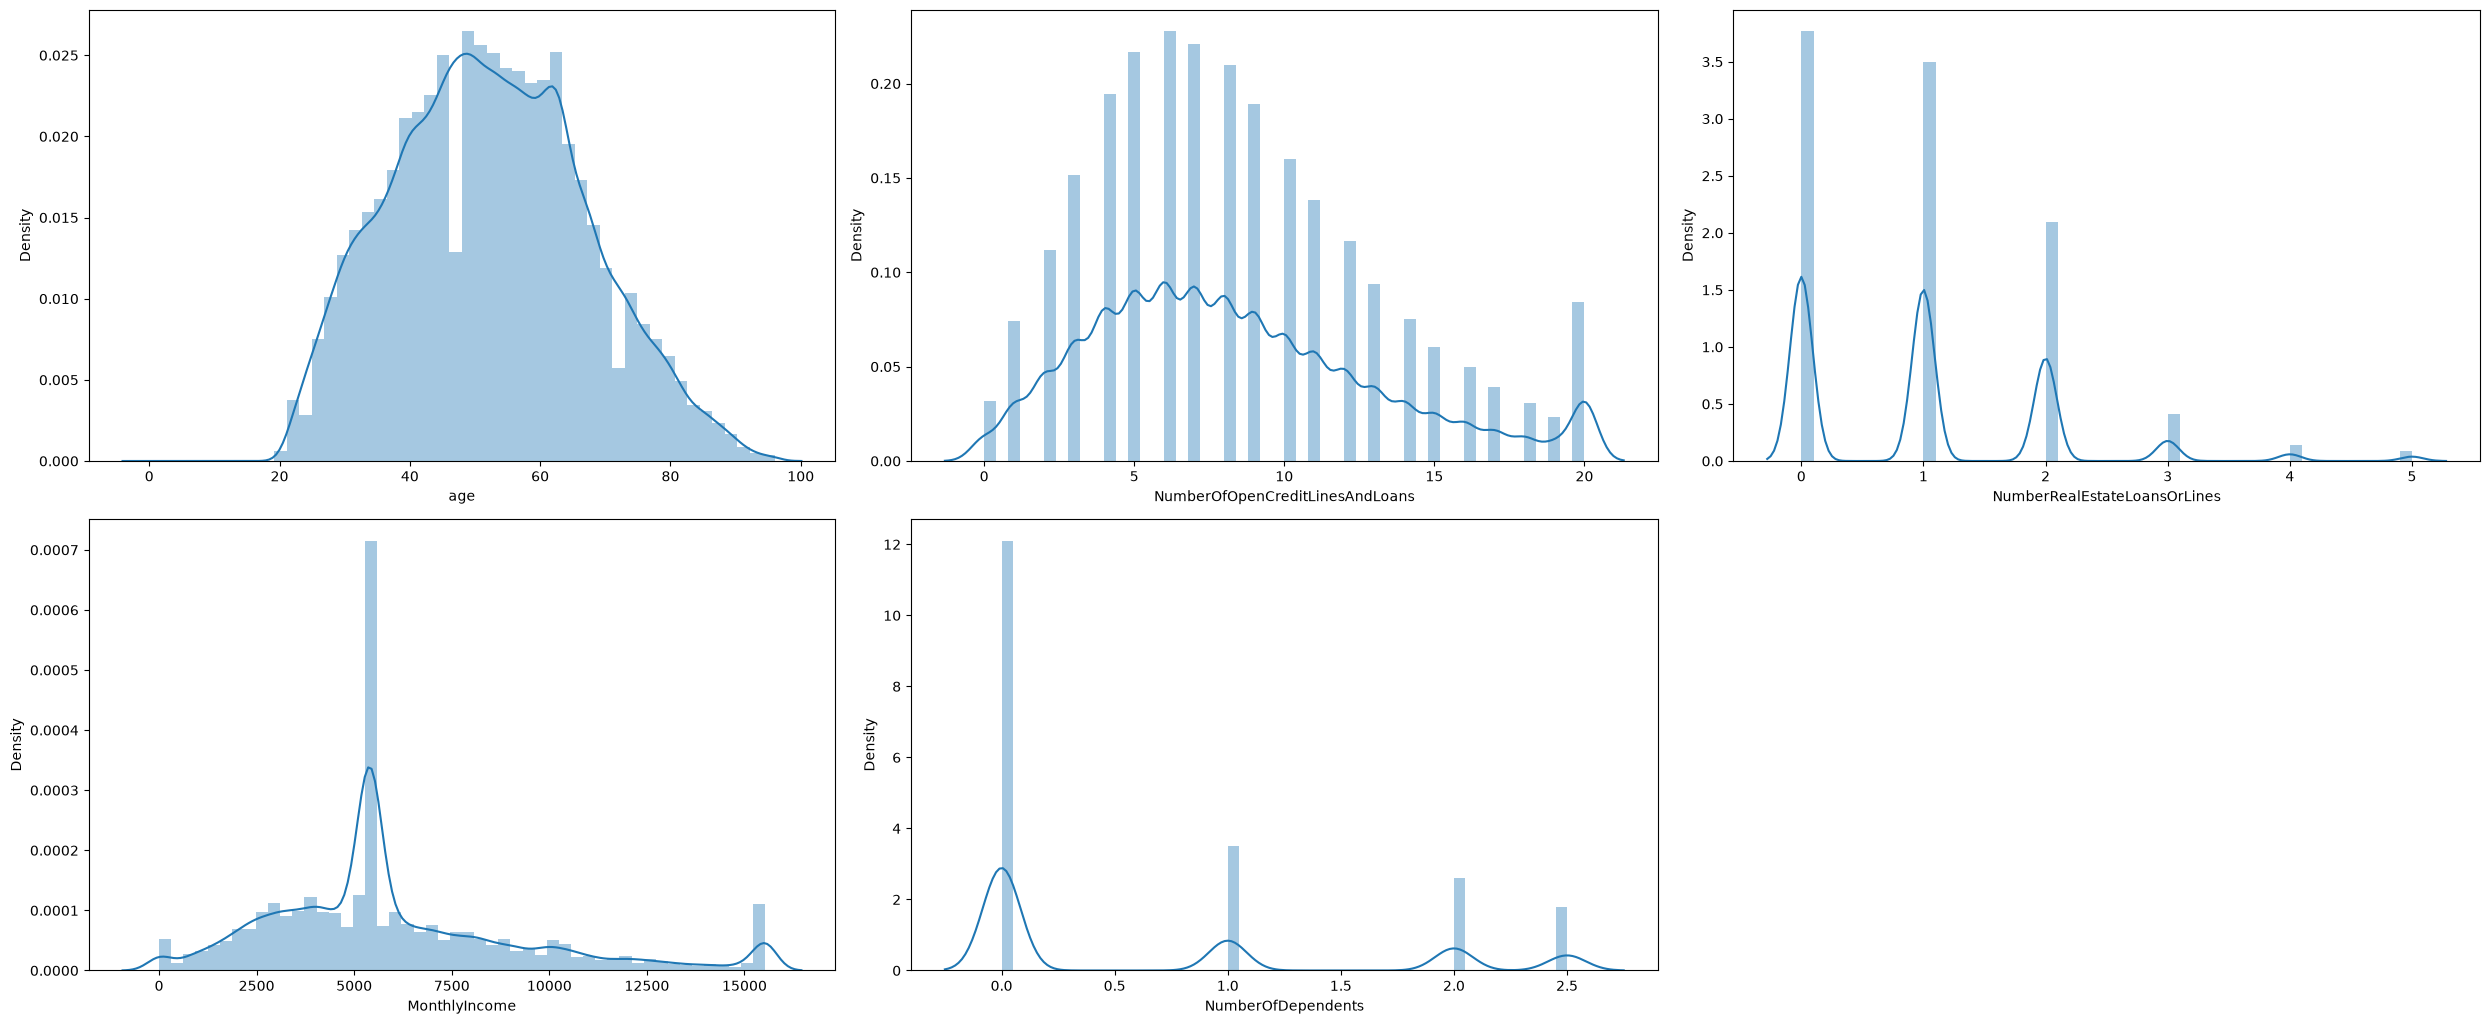

In [77]:
plt.figure(figsize=(25,15))

plt.subplot(3,3,1)
sns.distplot(data['age'])

plt.subplot(3,3,2)
sns.distplot(data['NumberOfOpenCreditLinesAndLoans'])

plt.subplot(3,3,3)
sns.distplot(data['NumberRealEstateLoansOrLines'])

plt.subplot(3,3,4)
sns.distplot(data['MonthlyIncome'])

plt.subplot(3,3,5)
sns.distplot(data['NumberOfDependents'])

plt.tight_layout()
plt.show()

# IQR Capping

In [78]:
def iqr_cap(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    upper = Q3 + 1.5 * IQR
    df[col] = df[col].clip(upper=upper)
    return df

In [79]:
cols_for_iqr = ['age', 'NumberOfOpenCreditLinesAndLoans', 'NumberRealEstateLoansOrLines', 'MonthlyIncome', 'NumberOfDependents']
for col in cols_for_iqr:
    data = iqr_cap(data, col)

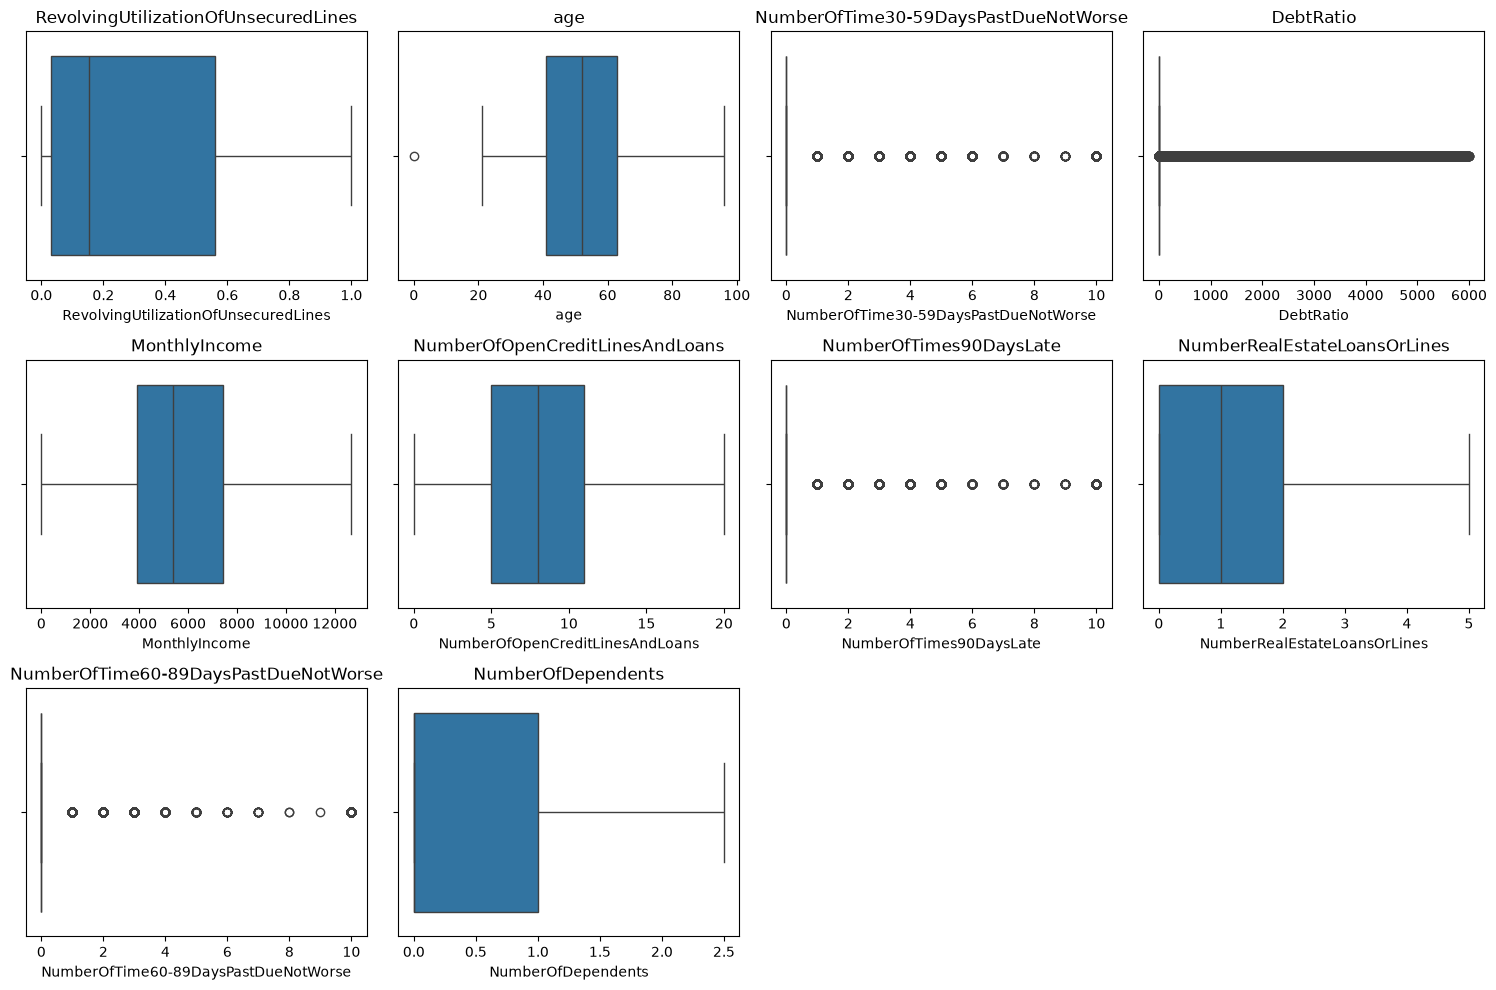

In [80]:
plt.figure(figsize=(15,10))

for i, col in enumerate(cols):
    plt.subplot(3,4,i+1)
    sns.boxplot(x=data[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [13]:
data['DebtRatio'].unique()

array([0.80298213, 0.1218762 , 0.08511338, ..., 0.40429286, 0.71656222,
       0.24990808], shape=(114194,))

In [ ]:
data=data[data['DebtRatio']<6000]

In [17]:
df.shape

(149173, 11)

In [18]:
# Because DebtRatio is highly right-skewed, and log makes extreme values less dominant while preserving order.
data['DebtRatio_log'] = np.log1p(data['DebtRatio'])

In [85]:
data.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,DebtRatio_log
0,1,0.766127,45,2,0.802982,9120.0,13,0,5,0,2.0,0.589442
1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0,0.115002
2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0,0.081684
3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0,0.035415
4,0,0.907239,49,1,0.024926,12680.0,7,0,1,0,0.0,0.024620


In [86]:
data['DebtRatio_log'].unique()

array([0.58944203, 0.11500246, 0.08168447, ..., 0.33953387, 0.54032358,
       0.22307001], shape=(113422,))

In [87]:
data.describe()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,DebtRatio_log
count,149173.000000,149173.000000,149173.000000,149173.000000,149173.000000,149173.00000,149173.000000,149173.000000,149173.000000,149173.000000,149173.00000,149173.000000
mean,0.066775,0.318966,52.280158,0.262715,292.773453,5883.77630,8.303621,0.108351,0.991855,0.082843,0.65904,1.483341
std,0.249632,0.349527,14.788200,0.809182,852.482649,3055.96909,4.725575,0.636981,1.007783,0.535360,0.90502,2.573313
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000
25%,0.000000,0.029832,41.000000,0.000000,0.173913,3900.00000,5.000000,0.000000,0.000000,0.000000,0.00000,0.160343
50%,0.000000,0.153785,52.000000,0.000000,0.364127,5400.00000,8.000000,0.000000,1.000000,0.000000,0.00000,0.310514
75%,0.000000,0.558684,63.000000,0.000000,0.838851,7412.00000,11.000000,0.000000,2.000000,0.000000,1.00000,0.609141
max,1.000000,1.000000,96.000000,10.000000,5998.000000,12680.00000,20.000000,10.000000,5.000000,10.000000,2.50000,8.699348


Missing income and dependent values were imputed using median to preserve distribution. Extreme delinquency counts and utilization values were capped to handle reporting artifacts. Debt ratio was log-transformed to reduce skewness

C:\Users\PRAKASH KANAUJIYA\AppData\Local\Temp\ipykernel_18092\117404030.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data['MonthlyIncome'])
C:\Users\PRAKASH KANAUJIYA\AppData\Local\Temp\ipykernel_18092\117404030.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data['NumberOfDependents'

<Axes: xlabel='NumberOfDependents', ylabel='Density'>

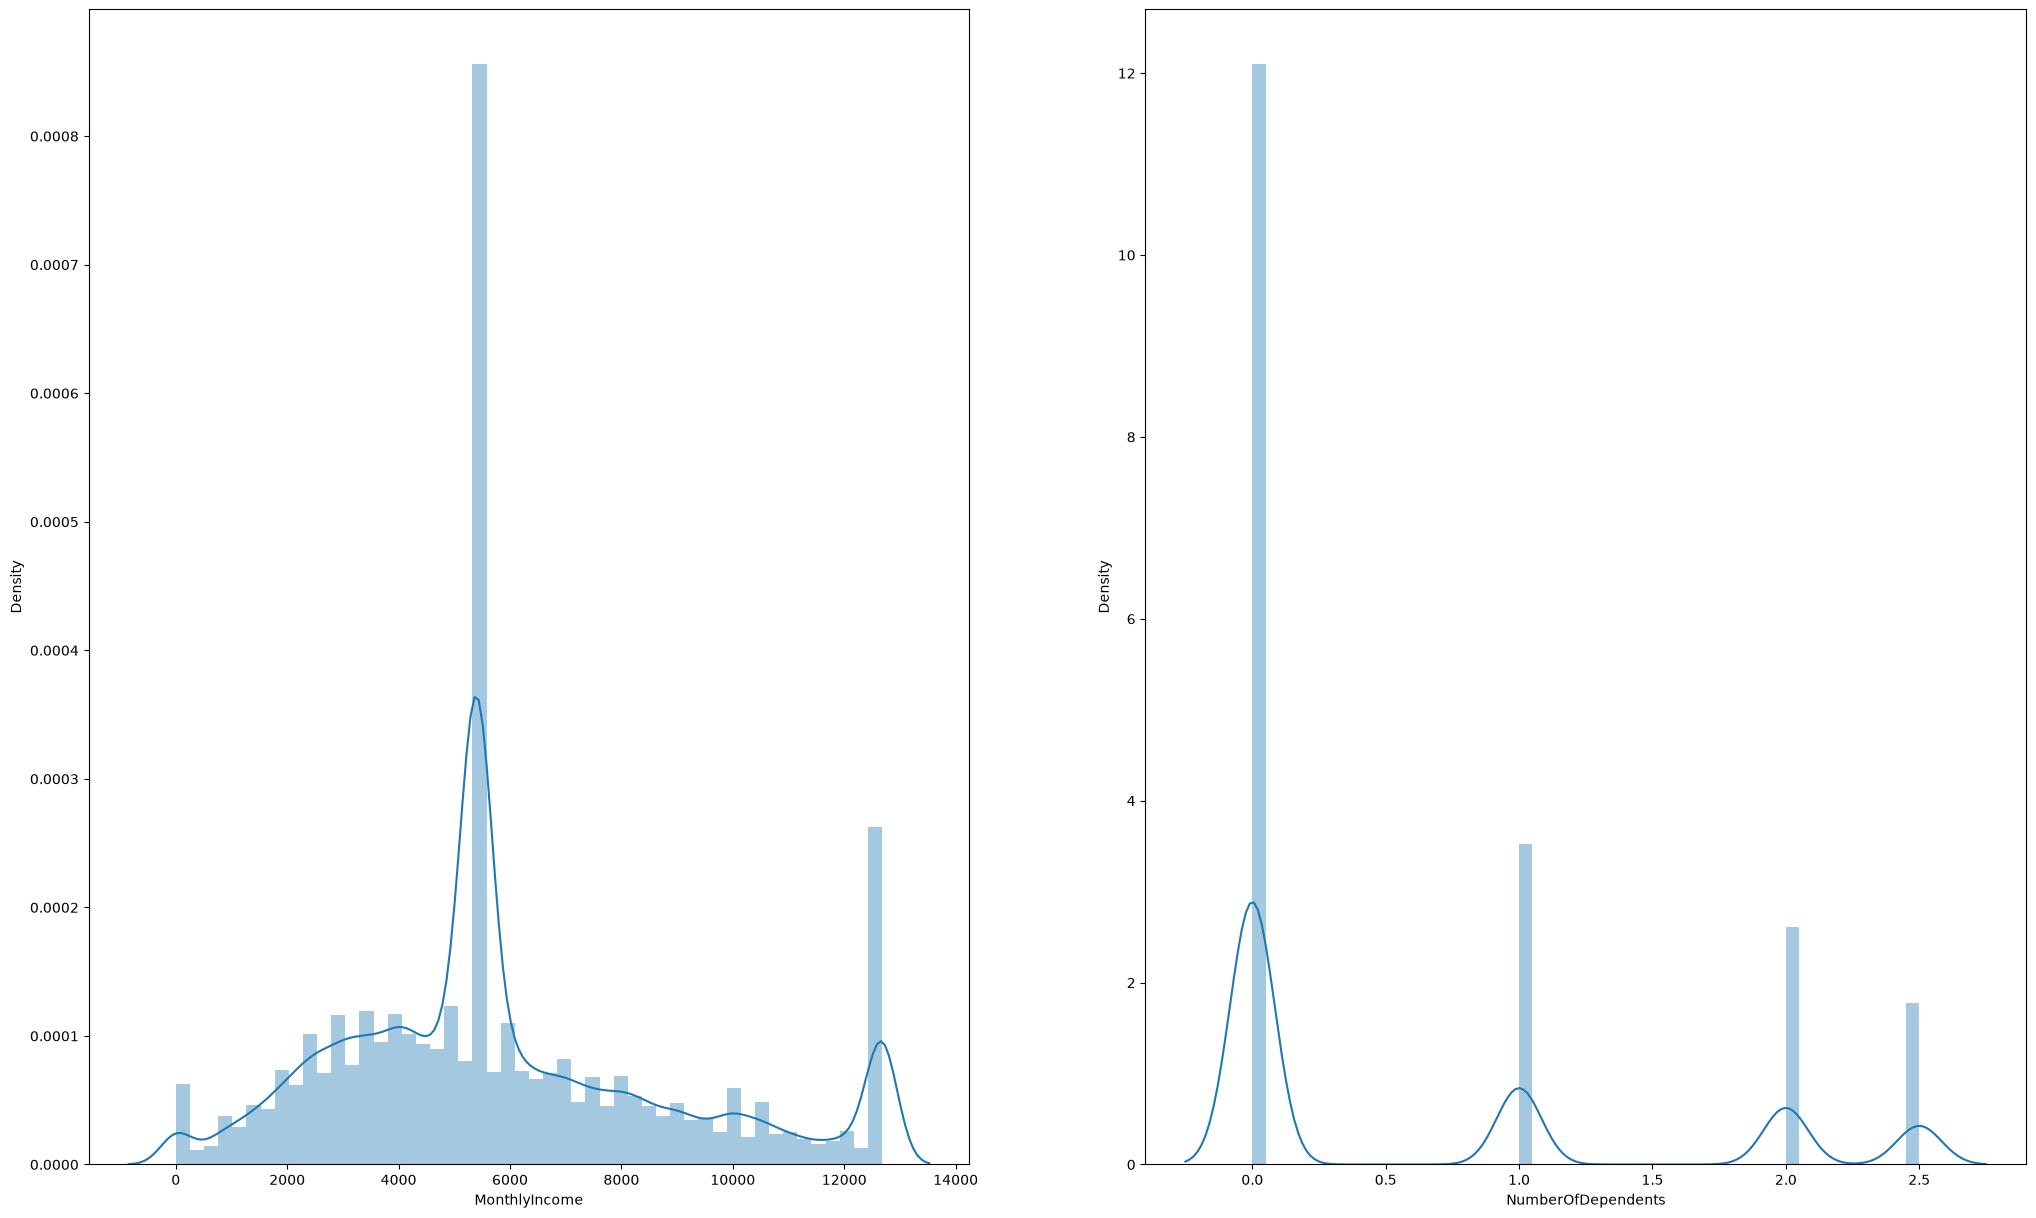

In [88]:
plt.figure(figsize=(25,15))

plt.subplot(1,2,1)
sns.distplot(data['MonthlyIncome'])

plt.subplot(1,2,2)
sns.distplot(data['NumberOfDependents'])


* Therefore NAN values in MonthlyIncome and NumberofDependent can be remove using median 

In [89]:
# Filling missing values in MonthlyIncome by median because Income is skewed and mean is distored by outliers
data['MonthlyIncome'] = data['MonthlyIncome'].fillna(
    data['MonthlyIncome'].median())

In [90]:
# Filling missing values in NumberOfDependents by median because NumberOfDependents is skewed and mean is distored by outliers 
data['NumberOfDependents'] = data['NumberOfDependents'].fillna(
    data['NumberOfDependents'].median())

In [91]:
data.isna().sum()

SeriousDlqin2yrs                        0
RevolvingUtilizationOfUnsecuredLines    0
age                                     0
NumberOfTime30-59DaysPastDueNotWorse    0
DebtRatio                               0
MonthlyIncome                           0
NumberOfOpenCreditLinesAndLoans         0
NumberOfTimes90DaysLate                 0
NumberRealEstateLoansOrLines            0
NumberOfTime60-89DaysPastDueNotWorse    0
NumberOfDependents                      0
DebtRatio_log                           0
dtype: int64

# Exploratory Data Analysis

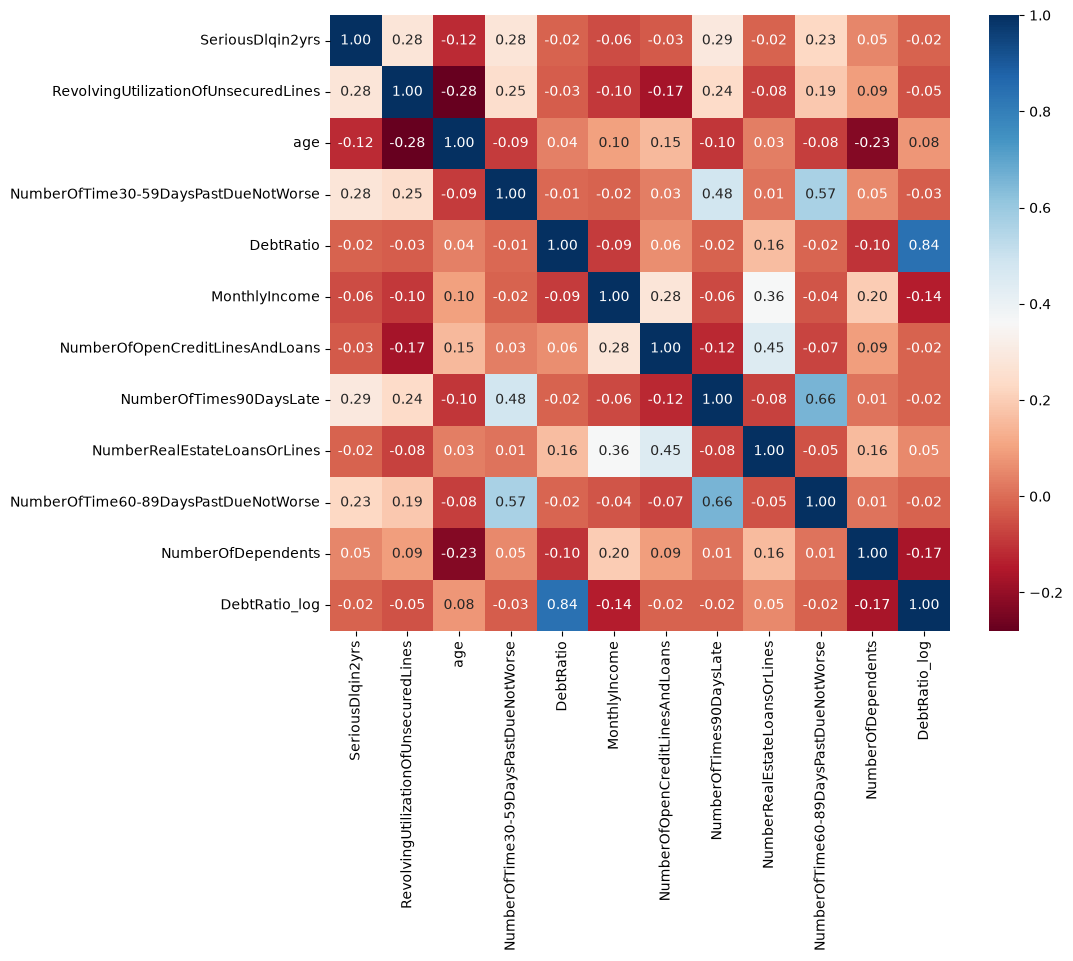

In [92]:
# Correlation Heatmap (Sanity Check)
plt.figure(figsize=(10,8))
sns.heatmap(data.corr(), cmap='RdBu',annot=True,fmt=".2f")
plt.show()

# Interpretation

* Delinquency variables correlated with target
* No extreme multicollinearity (except related delinquency counts)

# Age vs Default

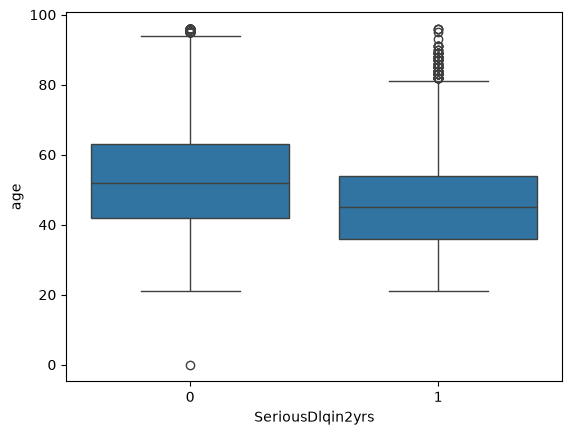

In [93]:
sns.boxplot(x='SeriousDlqin2yrs', y='age', data=data)
plt.show()

# Interpretation
Younger borrowers show higher default tendency due to lower financial stability.

# Revolving Utilization vs Default

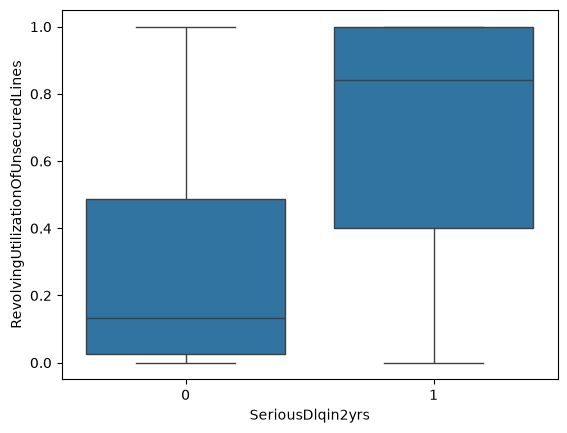

In [94]:
sns.boxplot(
    x='SeriousDlqin2yrs',
    y='RevolvingUtilizationOfUnsecuredLines',
    data=data
)
plt.show()

# Interpretation
High utilization reflects credit stress and is a leading indicator of default.

# Past Due Count vs Default

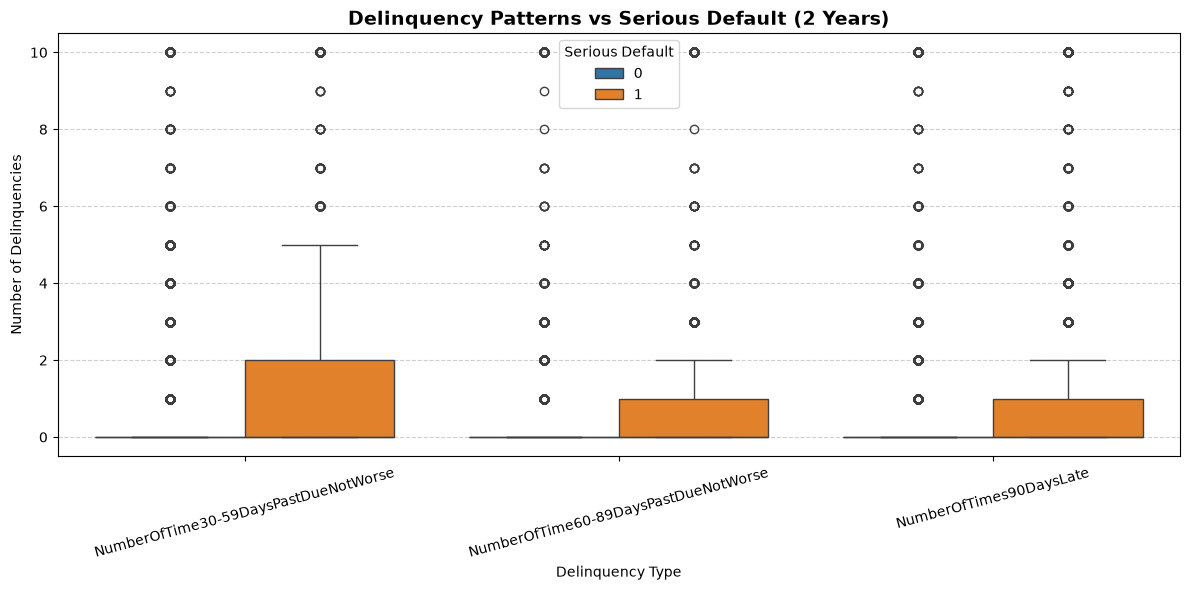

In [95]:
delinq_cols = [
    'NumberOfTime30-59DaysPastDueNotWorse',
    'NumberOfTime60-89DaysPastDueNotWorse',
    'NumberOfTimes90DaysLate'
]

# Convert to long format
df_long = data.melt(
    id_vars='SeriousDlqin2yrs',
    value_vars=delinq_cols,
    var_name='Delinquency Type',
    value_name='Number of Delinquencies'
)

# Plot
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df_long,
    x='Delinquency Type',
    y='Number of Delinquencies',
    hue='SeriousDlqin2yrs',
    showfliers=True
)

plt.title("Delinquency Patterns vs Serious Default (2 Years)", fontsize=14, fontweight='bold')
plt.xlabel("Delinquency Type")
plt.ylabel("Number of Delinquencies")

plt.xticks(rotation=15)
plt.legend(title="Serious Default")
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


# Feature Scaling

In [96]:
X = data.drop(columns=['SeriousDlqin2yrs'])
Y = data['SeriousDlqin2yrs']

In [97]:
# Stratified Sampling because the data is not balanced and default is a rare event as 
# business cares about catching defaulter
X_train, X_test, Y_train, Y_test = train_test_split(X, Y,test_size=0.2,random_state=42,stratify=Y)

## Applying Pipeline

In [98]:
numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

In [99]:
preprocessor = ColumnTransformer(transformers=[('num', numeric_pipeline, cols)])

# Logistic Regression

In [100]:
pipe_lr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000,class_weight='balanced'))
])

In [101]:
pipe_lr

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output o

In [102]:
pipe_lr.fit(X_train,Y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['RevolvingUtilizationOfUnsecuredLines','age', 'NumberOfTime30-59DaysPastDueNotWorse',..., 'NumberOfTime60-89DaysPastDueNotWorse','NumberOfDependents', 'DebtRatio_log']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolu

In [103]:
y_pred = pipe_lr.predict(X_test)
Y_prob_lr = pipe_lr.predict_proba(X_test)[:,1]
print(classification_report(Y_test, y_pred))
print("ROC_AUC_Score for logistic regression: ",roc_auc_score(Y_test, Y_prob_lr))

              precision    recall  f1-score   support

           0       0.98      0.80      0.88     27843
           1       0.21      0.75      0.33      1992

    accuracy                           0.80     29835
   macro avg       0.60      0.77      0.61     29835
weighted avg       0.93      0.80      0.84     29835

ROC_AUC_Score for logistic regression:  0.8558790706409303


confusion matrix


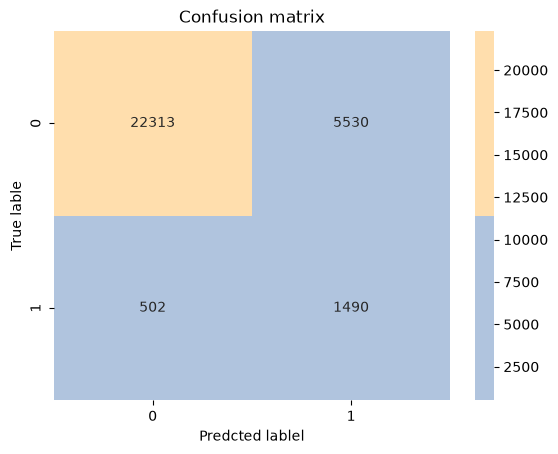

In [104]:
    print('confusion matrix')
    cm = confusion_matrix(Y_test,y_pred)
    sns.heatmap(cm, annot=True, fmt='d',cmap=['lightsteelblue','navajowhite'])
    plt.title('Confusion matrix')
    plt.xlabel('Predcted lablel')
    plt.ylabel('True lable')
    plt.show()

Normalized confusion matrix


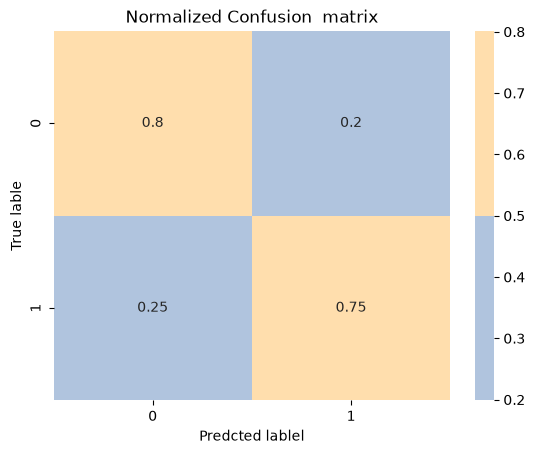

In [105]:
# confusion matrix without Normalization
print('Normalized confusion matrix')
cm1 = confusion_matrix(Y_test,y_pred, normalize='true')
sns.heatmap(cm1, annot=True,cmap=['lightsteelblue','navajowhite'])
plt.title('Normalized Confusion  matrix')
plt.xlabel('Predcted lablel')
plt.ylabel('True lable')
plt.show()

# Gradient Boosting 

In [106]:
from sklearn.ensemble import GradientBoostingClassifier
gb = GradientBoostingClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=3
)
final_pipeline = Pipeline(steps=[('preprocessor', preprocessor),('model', gb)])

In [107]:
final_pipeline.fit(X_train, Y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['RevolvingUtilizationOfUnsecuredLines','age', 'NumberOfTime30-59DaysPastDueNotWorse',..., 'NumberOfTime60-89DaysPastDueNotWorse','NumberOfDependents', 'DebtRatio_log']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns a

In [108]:
Y_prob = final_pipeline.predict_proba(X_test)[:,1]
Y_pred = (Y_prob > 0.3).astype(int)
print(classification_report(Y_test, y_pred))
print("ROC_AUC_sccore for Gradient Boosting",roc_auc_score(Y_test, Y_prob))

              precision    recall  f1-score   support

           0       0.98      0.80      0.88     27843
           1       0.21      0.75      0.33      1992

    accuracy                           0.80     29835
   macro avg       0.60      0.77      0.61     29835
weighted avg       0.93      0.80      0.84     29835

ROC_AUC_sccore for Gradient Boosting 0.8670388373881259


confusion matrix


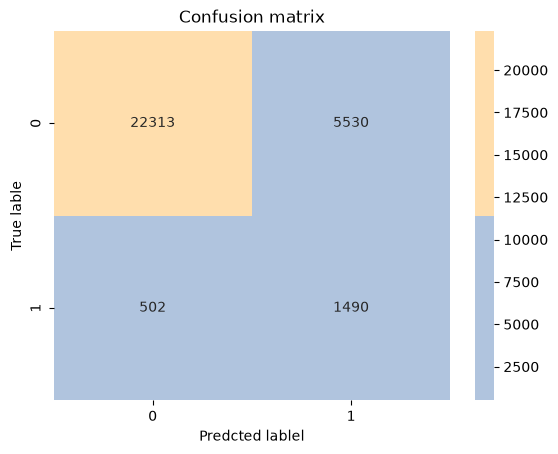

In [109]:
    print('confusion matrix')
    cm = confusion_matrix(Y_test,y_pred)
    sns.heatmap(cm, annot=True, fmt='d',cmap=['lightsteelblue','navajowhite'])
    plt.title('Confusion matrix')
    plt.xlabel('Predcted lablel')
    plt.ylabel('True lable')
    plt.show()

Normalized confusion matrix


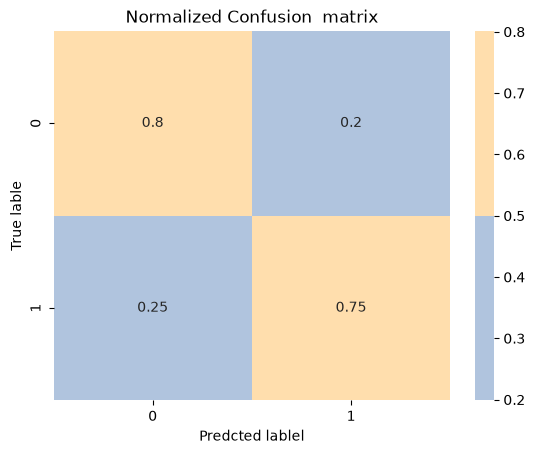

In [110]:
# confusion matrix without Normalization
print('Normalized confusion matrix')
cm1 = confusion_matrix(Y_test,y_pred, normalize='true')
sns.heatmap(cm1, annot=True,cmap=['lightsteelblue','navajowhite'])
plt.title('Normalized Confusion  matrix')
plt.xlabel('Predcted lablel')
plt.ylabel('True lable')
plt.show()

In [111]:
from imblearn.over_sampling import SMOTE

X_res, Y_res = SMOTE().fit_resample(X_train, Y_train)
final_pipeline.fit(X_res, Y_res)
y_pred = final_pipeline.predict(X_test)
Y_prob_lr = final_pipeline.predict_proba(X_test)[:,1]
print(classification_report(Y_test, y_pred))
print("ROC_AUC_Score for logistic regression: ",roc_auc_score(Y_test, Y_prob_lr))

ModuleNotFoundError: No module named 'imblearn'

confusion matrix


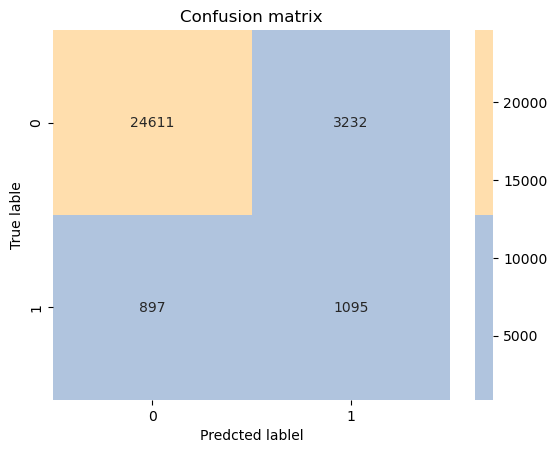

In [ ]:
    print('confusion matrix')
    cm = confusion_matrix(Y_test,y_pred)
    sns.heatmap(cm, annot=True, fmt='d',cmap=['lightsteelblue','navajowhite'])
    plt.title('Confusion matrix')
    plt.xlabel('Predcted lablel')
    plt.ylabel('True lable')
    plt.show()

Normalized confusion matrix


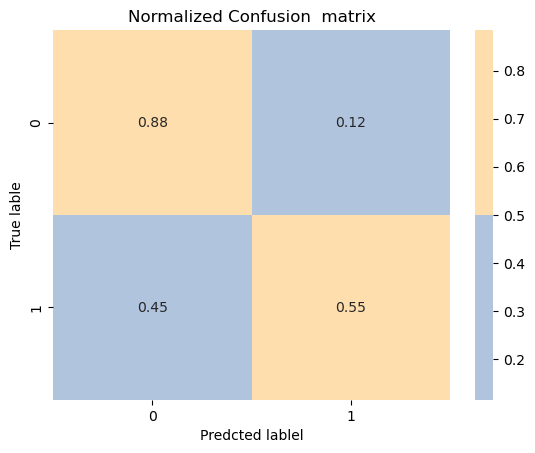

In [ ]:
# confusion matrix without Normalization
print('Normalized confusion matrix')
cm1 = confusion_matrix(Y_test,y_pred, normalize='true')
sns.heatmap(cm1, annot=True,cmap=['lightsteelblue','navajowhite'])
plt.title('Normalized Confusion  matrix')
plt.xlabel('Predcted lablel')
plt.ylabel('True lable')
plt.show()